In [ ]:
!pip install aif360
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
from aif360.metrics import BinaryLabelDatasetMetric

# Load data
df = pd.read_csv('adult.csv')
# Preprocess (encode categoricals, etc.)
# ... (add your preprocessing)
# Train model

# Add fairness checks with AIF360

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 259.7/259.7 kB 5.8 MB/s eta 0:00:00


pip install 'aif360[Reductions]'
pip install 'aif360[Reductions]'
pip install 'aif360[inFairness]'
pip install 'aif360[Reductions]'


In [ ]:
!pip install fairlearn datasets transformers[torch] accelerate -U

In [ ]:
!pip install fairlearn scikit-learn pandas matplotlib seaborn --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 251.6/251.6 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 20.9 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
import re
import time

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, confusion_matrix, accuracy_score,
    f1_score, roc_auc_score
)
from fairlearn.metrics import MetricFrame, false_positive_rate, selection_rate
from fairlearn.postprocessing import ThresholdOptimizer

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
print("✅ All imports loaded.")

✅ All imports loaded.


In [ ]:
df_full = pd.read_csv("all_data.csv", engine='python', quotechar='"', on_bad_lines='warn')
print(f"Full dataset shape: {df_full.shape}")

Full dataset shape: (872089, 46)


In [ ]:
# Sample 100,000 rows for tractability
df = df_full.sample(n=100_000, random_state=42).reset_index(drop=True)
print(f"Sampled dataset shape: {df.shape}")

Sampled dataset shape: (100000, 46)


In [ ]:
# Define protected attribute columns
PROTECTED_COLS = [
    "asian", "black", "white",
    "christian", "muslim",
    "homosexual_gay_or_lesbian"
]

In [ ]:
# Friendly display names for plots
IDENTITY_LABELS = {
    "asian": "Asian",
    "black": "Black",
    "white": "White",
    "christian": "Christian",
    "muslim": "Muslim",
    "homosexual_gay_or_lesbian": "LGBTQ+"
}

In [ ]:
# Fill missing values in identity columns with 0
for col in PROTECTED_COLS:
    if col in df.columns:
        df[col] = df[col].fillna(0.0)
    else:
        print(f"⚠️  Column '{col}' not found — creating with zeros.")
        df[col] = 0.0

In [ ]:
for col in PROTECTED_COLS:
    df[col] = (df[col] >= 0.5).astype(int)

In [ ]:
df["toxic"] = (df["toxicity"] >= 0.5).astype(int)

In [ ]:
# Handle missing comment text
df["comment_text"] = df["comment_text"].fillna("").astype(str)

In [ ]:
print(f"\nTarget distribution:\n{df['toxic'].value_counts(normalize=True).round(4)}")
print(f"\nIdentity mention counts:")
for col in PROTECTED_COLS:
    print(f"  {IDENTITY_LABELS[col]:12s}: {df[col].sum():,} comments")

print("\n✅ Data cleaning complete.")


Target distribution:
toxic
0    0.9109
1    0.0891
Name: proportion, dtype: float64

Identity mention counts:
  Asian       : 45 comments
  Black       : 301 comments
  White       : 422 comments
  Christian   : 268 comments
  Muslim      : 279 comments
  LGBTQ+      : 168 comments

✅ Data cleaning complete.


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 4 — Text Preprocessing & Feature Extraction                         ║
# ╚══════════════════════════════════════════════════════════════════════════════╝


In [ ]:
print("Vectorizing text with TF-IDF (this may take ~30s)...")
start = time.time()
vectorizer = TfidfVectorizer(
    max_features=50_000,
    ngram_range=(1, 2),
    min_df=3,
    max_df=0.9,
    strip_accents="unicode",
    sublinear_tf=True
)

X = vectorizer.fit_transform(df["comment_text"])
y = df["toxic"].values

elapsed = time.time() - start
print(f"TF-IDF matrix shape: {X.shape}  ({elapsed:.1f}s)")

Vectorizing text with TF-IDF (this may take ~30s)...
TF-IDF matrix shape: (100000, 50000)  (17.1s)


In [ ]:
# Train / Test split (stratified)
X_train, X_test, y_train, y_test, idx_train, idx_test = train_test_split(
    X, y, df.index, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
# Extract protected attributes aligned with test set
A_test = df.loc[idx_test, PROTECTED_COLS].reset_index(drop=True)

print(f"Train size: {X_train.shape[0]:,}  |  Test size: {X_test.shape[0]:,}")
print("✅ Feature extraction complete.")

Train size: 80,000  |  Test size: 20,000
✅ Feature extraction complete.


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 5 — Baseline Model Training (Logistic Regression)                   ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

In [ ]:
print("Training Logistic Regression baseline...")
start = time.time()

model = LogisticRegression(
    C=1.0,
    max_iter=1000,
    solver="liblinear",
    class_weight="balanced",   # helps with class imbalance
    random_state=42
)
model.fit(X_train, y_train)

Training Logistic Regression baseline...


LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42,
                   solver='liblinear')

In [ ]:
elapsed = time.time() - start
y_pred_baseline = model.predict(X_test)
y_prob_baseline = model.predict_proba(X_test)[:, 1]

In [ ]:
print(f"Training time: {elapsed:.1f}s")
print(f"\n{'='*60}")
print("BASELINE MODEL — Classification Report")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_baseline, target_names=["Non-Toxic", "Toxic"]))
print(f"ROC-AUC: {roc_auc_score(y_test, y_prob_baseline):.4f}")
print("✅ Baseline model trained.")

Training time: 27.6s

BASELINE MODEL — Classification Report
              precision    recall  f1-score   support

   Non-Toxic       0.99      0.97      0.98     18218
       Toxic       0.72      0.85      0.78      1782

    accuracy                           0.96     20000
   macro avg       0.85      0.91      0.88     20000
weighted avg       0.96      0.96      0.96     20000

ROC-AUC: 0.9727
✅ Baseline model trained.


# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 6 — Bias Audit (Fairlearn)                                          ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

In [ ]:
print("Running Bias Audit on baseline predictions...\n")

Running Bias Audit on baseline predictions...



In [ ]:
# We compute per-identity FPR and Selection Rate
# For each identity, we compare rows where identity==1 vs identity==0

bias_results = []

for col in PROTECTED_COLS:
    sensitive = A_test[col].values

    mf = MetricFrame(
        metrics={
            "false_positive_rate": false_positive_rate,
            "selection_rate": selection_rate,
            "accuracy": accuracy_score,
        },
        y_true=y_test,
        y_pred=y_pred_baseline,
        sensitive_features=sensitive
    )

    by_group = mf.by_group
    # Group 1 = identity mentioned, Group 0 = not mentioned
    for grp_val in [0, 1]:
        if grp_val in by_group.index:
            row = by_group.loc[grp_val]
            bias_results.append({
                "identity": IDENTITY_LABELS[col],
                "group": "Mentioned" if grp_val == 1 else "Not Mentioned",
                "FPR": row["false_positive_rate"],
                "Selection Rate": row["selection_rate"],
                "Accuracy": row["accuracy"],
            })

bias_df = pd.DataFrame(bias_results)

In [ ]:
print("╔══════════════════════════════════════════════════════════════╗")
print("║             BIAS AUDIT — Baseline Model                    ║")
print("╠══════════════════════════════════════════════════════════════╣")
for identity in IDENTITY_LABELS.values():
    subset = bias_df[bias_df["identity"] == identity]
    mentioned = subset[subset["group"] == "Mentioned"]
    not_mentioned = subset[subset["group"] == "Not Mentioned"]
    if len(mentioned) > 0 and len(not_mentioned) > 0:
        fpr_m = mentioned["FPR"].values[0]
        fpr_nm = not_mentioned["FPR"].values[0]
        gap = fpr_m - fpr_nm
        flag = " ⚠️  BIASED" if abs(gap) > 0.05 else " ✓"
        print(f"  {identity:12s} | FPR(mentioned)={fpr_m:.4f}  FPR(other)={fpr_nm:.4f}  Gap={gap:+.4f}{flag}")
print("╚══════════════════════════════════════════════════════════════╝")
print()
print(bias_df.to_string(index=False))
print("\n✅ Bias audit complete.")

╔══════════════════════════════════════════════════════════════╗
║             BIAS AUDIT — Baseline Model                    ║
╠══════════════════════════════════════════════════════════════╣
  Asian        | FPR(mentioned)=0.0000  FPR(other)=0.0328  Gap=-0.0328 ✓
  Black        | FPR(mentioned)=0.6522  FPR(other)=0.0320  Gap=+0.6201 ⚠️  BIASED
  White        | FPR(mentioned)=0.8400  FPR(other)=0.0317  Gap=+0.8083 ⚠️  BIASED
  Christian    | FPR(mentioned)=0.1429  FPR(other)=0.0327  Gap=+0.1102 ⚠️  BIASED
  Muslim       | FPR(mentioned)=0.4667  FPR(other)=0.0325  Gap=+0.4342 ⚠️  BIASED
  LGBTQ+       | FPR(mentioned)=0.3636  FPR(other)=0.0326  Gap=+0.3310 ⚠️  BIASED
╚══════════════════════════════════════════════════════════════╝

 identity         group      FPR  Selection Rate  Accuracy
    Asian Not Mentioned 0.032832        0.105637  0.956835
    Asian     Mentioned 0.000000        0.428571  1.000000
    Black Not Mentioned 0.032042        0.103156  0.957554
    Black     Mentione

# ╔══════════════════════════════════════════════════════════════════════════════╗
# ║  CELL 7 — Mitigation: Post-Processing Threshold Optimizer                 ║
# ╚══════════════════════════════════════════════════════════════════════════════╝

# We create a combined sensitive feature for multi-group optimization.
# Each row gets a label like "asian" if that identity is mentioned, else "none".
# If multiple identities are mentioned, we pick the first one found.

In [ ]:
def assign_sensitive_label(row):
    for col in PROTECTED_COLS:
        if row[col] == 1:
            return IDENTITY_LABELS[col]
    return "None"

A_train_df = df.loc[idx_train, PROTECTED_COLS].reset_index(drop=True)
A_test_df  = A_test.copy()

sensitive_train = A_train_df.apply(assign_sensitive_label, axis=1).values
sensitive_test  = A_test_df.apply(assign_sensitive_label, axis=1).values

print("Sensitive group distribution (test set):")
unique, counts = np.unique(sensitive_test, return_counts=True)
for u, c in zip(unique, counts):
    print(f"  {u:12s}: {c:,}")

print("\nTraining ThresholdOptimizer (equalizing FPR)...")
start = time.time()

postprocess = ThresholdOptimizer(
    estimator=model,
    constraints="false_positive_rate_parity",
    objective="accuracy_score",
    prefit=True,
    predict_method="predict_proba"
)

# Convert X_train and X_test to dense arrays
postprocess.fit(X_train.toarray(), y_train, sensitive_features=sensitive_train)
y_pred_mitigated = postprocess.predict(X_test.toarray(), sensitive_features=sensitive_test)

elapsed = time.time() - start
print(f"Optimization time: {elapsed:.1f}s")

print(f"\n{'='*60}")
print("MITIGATED MODEL — Classification Report")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_mitigated, target_names=["Non-Toxic", "Toxic"]))
print("✅ Mitigation complete.")


Sensitive group distribution (test set):
  Asian       : 7
  Black       : 66
  Christian   : 52
  LGBTQ+      : 31
  Muslim      : 36
  None        : 19,758
  White       : 50

Training ThresholdOptimizer (equalizing FPR)...
Optimization time: 23.9s

MITIGATED MODEL — Classification Report
              precision    recall  f1-score   support

   Non-Toxic       0.97      0.98      0.98     18218
       Toxic       0.80      0.72      0.76      1782

    accuracy                           0.96     20000
   macro avg       0.89      0.85      0.87     20000
weighted avg       0.96      0.96      0.96     20000

✅ Mitigation complete.


In [ ]:
mitigated_bias = []

for col in PROTECTED_COLS:
    sensitive = A_test[col].values

    mf = MetricFrame(
        metrics={
            "false_positive_rate": false_positive_rate,
            "selection_rate": selection_rate,
            "accuracy": accuracy_score,
        },
        y_true=y_test,
        y_pred=y_pred_mitigated,
        sensitive_features=sensitive
    )

    by_group = mf.by_group
    for grp_val in [0, 1]:
        if grp_val in by_group.index:
            row = by_group.loc[grp_val]
            mitigated_bias.append({
                "identity": IDENTITY_LABELS[col],
                "group": "Mentioned" if grp_val == 1 else "Not Mentioned",
                "FPR": row["false_positive_rate"],
                "Selection Rate": row["selection_rate"],
                "Accuracy": row["accuracy"],
            })

mitigated_df = pd.DataFrame(mitigated_bias)

print("╔══════════════════════════════════════════════════════════════╗")
print("║          BIAS AUDIT — After Mitigation                     ║")
print("╠══════════════════════════════════════════════════════════════╣")
for identity in IDENTITY_LABELS.values():
    subset = mitigated_df[mitigated_df["identity"] == identity]
    mentioned = subset[subset["group"] == "Mentioned"]
    not_mentioned = subset[subset["group"] == "Not Mentioned"]
    if len(mentioned) > 0 and len(not_mentioned) > 0:
        fpr_m = mentioned["FPR"].values[0]
        fpr_nm = not_mentioned["FPR"].values[0]
        gap = fpr_m - fpr_nm
        flag = " ⚠️  BIASED" if abs(gap) > 0.05 else " ✓"
        print(f"  {identity:12s} | FPR(mentioned)={fpr_m:.4f}  FPR(other)={fpr_nm:.4f}  Gap={gap:+.4f}{flag}")
print("╚══════════════════════════════════════════════════════════════╝")
print("\n✅ Post-mitigation audit complete.")

╔══════════════════════════════════════════════════════════════╗
║          BIAS AUDIT — After Mitigation                     ║
╠══════════════════════════════════════════════════════════════╣
  Asian        | FPR(mentioned)=0.0000  FPR(other)=0.0172  Gap=-0.0172 ✓
  Black        | FPR(mentioned)=0.0000  FPR(other)=0.0172  Gap=-0.0172 ✓
  White        | FPR(mentioned)=0.0400  FPR(other)=0.0171  Gap=+0.0229 ✓
  Christian    | FPR(mentioned)=0.0476  FPR(other)=0.0171  Gap=+0.0305 ✓
  Muslim       | FPR(mentioned)=0.0000  FPR(other)=0.0172  Gap=-0.0172 ✓
  LGBTQ+       | FPR(mentioned)=0.0909  FPR(other)=0.0171  Gap=+0.0738 ⚠️  BIASED
╚══════════════════════════════════════════════════════════════╝

✅ Post-mitigation audit complete.


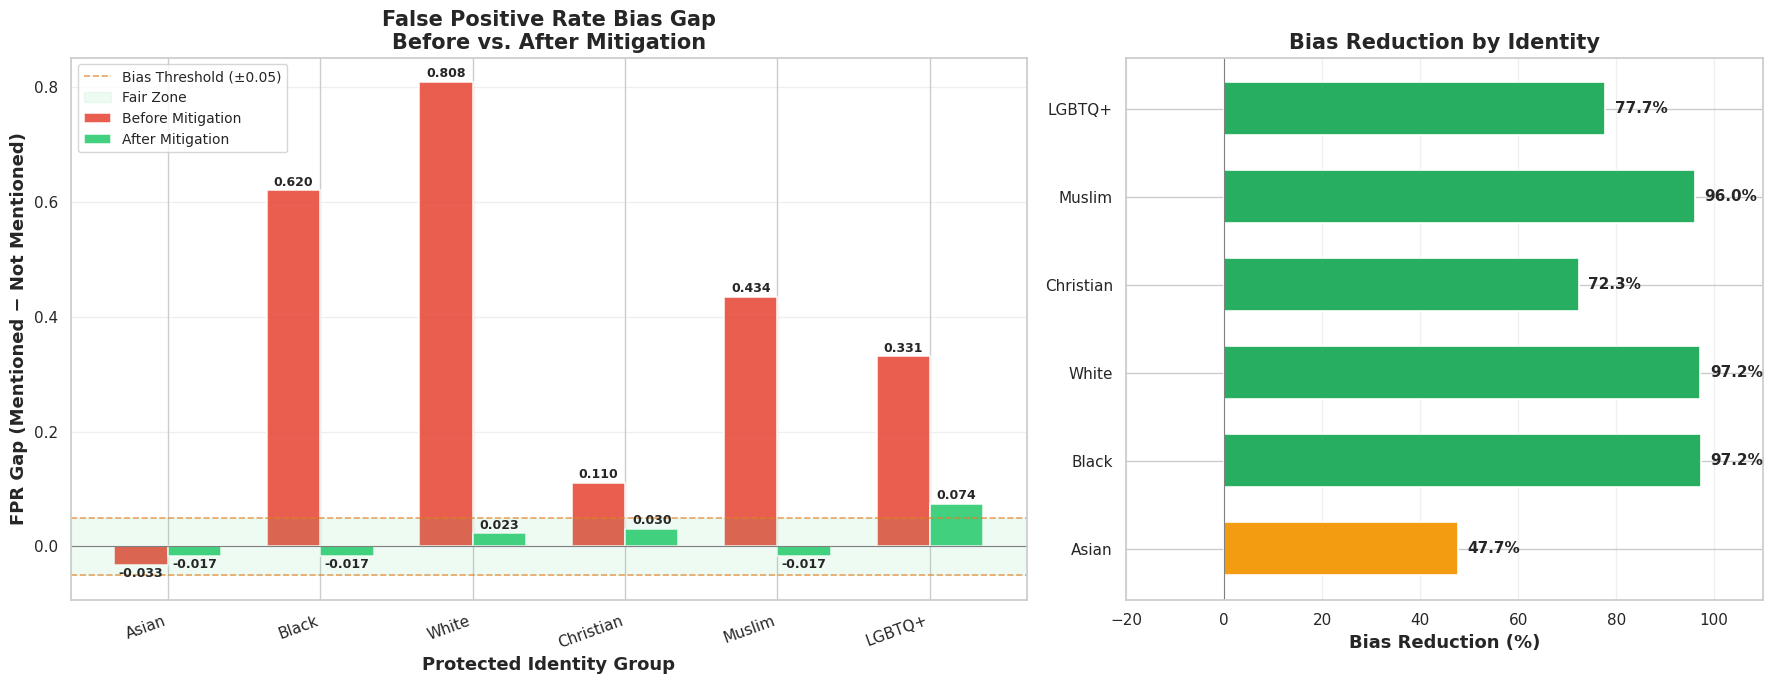

✅ Figure saved: bias_gap_comparison.png


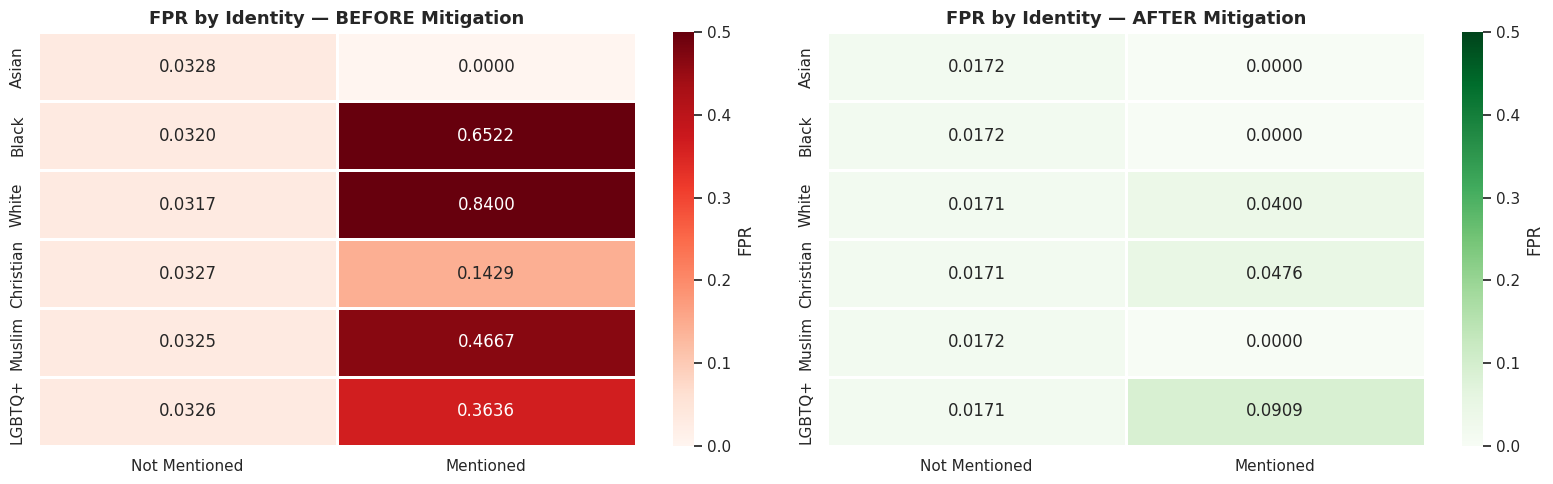

✅ Figure saved: fpr_heatmaps.png


In [ ]:
#Visualization: Bias Gap Before vs After Mitigation

def extract_fpr_gaps(result_df):
    gaps = {}
    for identity in IDENTITY_LABELS.values():
        subset = result_df[result_df["identity"] == identity]
        mentioned = subset[subset["group"] == "Mentioned"]
        not_mentioned = subset[subset["group"] == "Not Mentioned"]
        if len(mentioned) > 0 and len(not_mentioned) > 0:
            gaps[identity] = mentioned["FPR"].values[0] - not_mentioned["FPR"].values[0]
    return gaps

baseline_gaps = extract_fpr_gaps(bias_df)
mitigated_gaps = extract_fpr_gaps(mitigated_df)

identities = list(baseline_gaps.keys())
gaps_before = [baseline_gaps[i] for i in identities]
gaps_after  = [mitigated_gaps.get(i, 0) for i in identities]

# ── FIGURE 1: FPR Gap Comparison (Grouped Bar Chart) ──
fig, axes = plt.subplots(1, 2, figsize=(18, 7), gridspec_kw={"width_ratios": [3, 2]})

# Left panel: Grouped bar chart
x = np.arange(len(identities))
width = 0.35

colors_before = "#E74C3C"   # Red
colors_after  = "#2ECC71"   # Green

bars1 = axes[0].bar(x - width/2, gaps_before, width, label="Before Mitigation",
                     color=colors_before, edgecolor="white", linewidth=1.2, alpha=0.9)
bars2 = axes[0].bar(x + width/2, gaps_after, width, label="After Mitigation",
                     color=colors_after, edgecolor="white", linewidth=1.2, alpha=0.9)

axes[0].axhline(y=0, color="gray", linestyle="-", linewidth=0.8)
axes[0].axhline(y=0.05, color="#E67E22", linestyle="--", linewidth=1.2, alpha=0.7, label="Bias Threshold (±0.05)")
axes[0].axhline(y=-0.05, color="#E67E22", linestyle="--", linewidth=1.2, alpha=0.7)
axes[0].axhspan(-0.05, 0.05, alpha=0.08, color="#2ECC71", label="Fair Zone")

axes[0].set_xlabel("Protected Identity Group", fontsize=13, fontweight="bold")
axes[0].set_ylabel("FPR Gap (Mentioned − Not Mentioned)", fontsize=13, fontweight="bold")
axes[0].set_title("False Positive Rate Bias Gap\nBefore vs. After Mitigation", fontsize=15, fontweight="bold")
axes[0].set_xticks(x)
axes[0].set_xticklabels(identities, fontsize=11, rotation=20, ha="right")
axes[0].legend(fontsize=10, loc="upper left")
axes[0].grid(axis="y", alpha=0.3)

# Add value labels on bars
for bar in bars1:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.003 * np.sign(h),
                 f"{h:.3f}", ha="center", va="bottom" if h >= 0 else "top", fontsize=9, fontweight="bold")
for bar in bars2:
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 0.003 * np.sign(h),
                 f"{h:.3f}", ha="center", va="bottom" if h >= 0 else "top", fontsize=9, fontweight="bold")

# Right panel: Reduction percentage
reductions = []
for b, a in zip(gaps_before, gaps_after):
    if abs(b) > 0.001:
        reductions.append((1 - abs(a) / abs(b)) * 100)
    else:
        reductions.append(0)

bar_colors = ["#27AE60" if r > 50 else "#F39C12" if r > 0 else "#E74C3C" for r in reductions]
bars3 = axes[1].barh(identities, reductions, color=bar_colors, edgecolor="white", linewidth=1.2, height=0.6)
axes[1].set_xlabel("Bias Reduction (%)", fontsize=13, fontweight="bold")
axes[1].set_title("Bias Reduction by Identity", fontsize=15, fontweight="bold")
axes[1].axvline(x=0, color="gray", linewidth=0.8)
axes[1].set_xlim(-20, 110)
axes[1].grid(axis="x", alpha=0.3)

for bar, val in zip(bars3, reductions):
    axes[1].text(bar.get_width() + 2, bar.get_y() + bar.get_height()/2.,
                 f"{val:.1f}%", ha="left", va="center", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("bias_gap_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure saved: bias_gap_comparison.png")

# ── FIGURE 2: FPR Heatmap Before & After ──
fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

def build_fpr_matrix(result_df):
    matrix = {}
    for identity in IDENTITY_LABELS.values():
        subset = result_df[result_df["identity"] == identity]
        for _, row in subset.iterrows():
            matrix[(identity, row["group"])] = row["FPR"]
    df_matrix = pd.DataFrame(index=IDENTITY_LABELS.values(), columns=["Not Mentioned", "Mentioned"])
    for identity in IDENTITY_LABELS.values():
        df_matrix.loc[identity, "Mentioned"] = matrix.get((identity, "Mentioned"), 0)
        df_matrix.loc[identity, "Not Mentioned"] = matrix.get((identity, "Not Mentioned"), 0)
    return df_matrix.astype(float)

hm_before = build_fpr_matrix(bias_df)
hm_after  = build_fpr_matrix(mitigated_df)

sns.heatmap(hm_before, annot=True, fmt=".4f", cmap="Reds", ax=ax1, vmin=0, vmax=0.5,
            linewidths=1, linecolor="white", cbar_kws={"label": "FPR"})
ax1.set_title("FPR by Identity — BEFORE Mitigation", fontsize=13, fontweight="bold")
ax1.set_ylabel("")

sns.heatmap(hm_after, annot=True, fmt=".4f", cmap="Greens", ax=ax2, vmin=0, vmax=0.5,
            linewidths=1, linecolor="white", cbar_kws={"label": "FPR"})
ax2.set_title("FPR by Identity — AFTER Mitigation", fontsize=13, fontweight="bold")
ax2.set_ylabel("")

plt.tight_layout()
plt.savefig("fpr_heatmaps.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure saved: fpr_heatmaps.png")

In [ ]:
 # Gaming Context Test: Non-Toxic Slang Misclassification

 gaming_slang = [
    # Competitive / hype language
    "That play was sick!",
    "Get rekt noob",
    "Beast mode activated",
    "You're insane bro, that clutch was godlike",
    "Absolutely destroyed them in that round",
    "I'm going to murder this boss fight",
    "Kill streak! Let's go!",
    "GG EZ, we stomped them",
    "You're trash, uninstall the game",
    "Clapped the whole enemy squad",
    # Friendly trash talk
    "Bro you got bodied lmao",
    "That was a filthy play, respect",
    "Diff gap is massive, jungle diff",
    "Stop feeding and play safe",
    "You're literally griefing right now",
    # Identity-mentioning but non-toxic
    "The new Muslim character skin looks amazing",
    "Asian servers have way better players",
    "My Christian guild is doing a charity stream",
    "Black panther skin is the best in the game",
    "The gay pride event items are fire",
    # Clearly non-toxic
    "Good game everyone, that was fun",
    "Anyone want to queue up for another round?",
    "Nice shot! How did you hit that?",
    "Can someone help me with this quest?",
    "First time playing this map, any tips?",
]

gaming_labels_true = [0]*25  # All are non-toxic (ground truth)

# Vectorize and predict
X_gaming = vectorizer.transform(gaming_slang)
gaming_pred_baseline = model.predict(X_gaming)
gaming_prob_baseline = model.predict_proba(X_gaming)[:, 1]

# Display results
print("╔══════════════════════════════════════════════════════════════════════════╗")
print("║          GAMING SLANG TEST — Baseline Model Predictions               ║")
print("╠══════════════════════════════════════════════════════════════════════════╣")
misclass_count = 0
for i, (text, pred, prob) in enumerate(zip(gaming_slang, gaming_pred_baseline, gaming_prob_baseline)):
    label = "🚫 TOXIC" if pred == 1 else "✅ OK   "
    flag = " ← FALSE POSITIVE!" if pred == 1 else ""
    if pred == 1:
        misclass_count += 1
    print(f"  {label} (p={prob:.3f}) │ \"{text}\"{flag}")

total = len(gaming_slang)
print(f"╠══════════════════════════════════════════════════════════════════════════╣")
print(f"║  False Positive Rate on Gaming Slang: {misclass_count}/{total} = {misclass_count/total:.1%}              ║")
print(f"║  These are ALL non-toxic — every flag is a wrongful ban!              ║")
print(f"╚══════════════════════════════════════════════════════════════════════════╝")

╔══════════════════════════════════════════════════════════════════════════╗
║          GAMING SLANG TEST — Baseline Model Predictions               ║
╠══════════════════════════════════════════════════════════════════════════╣
  🚫 TOXIC (p=0.895) │ "That play was sick!" ← FALSE POSITIVE!
  ✅ OK    (p=0.359) │ "Get rekt noob"
  ✅ OK    (p=0.272) │ "Beast mode activated"
  🚫 TOXIC (p=0.762) │ "You're insane bro, that clutch was godlike" ← FALSE POSITIVE!
  ✅ OK    (p=0.224) │ "Absolutely destroyed them in that round"
  ✅ OK    (p=0.346) │ "I'm going to murder this boss fight"
  🚫 TOXIC (p=0.786) │ "Kill streak! Let's go!" ← FALSE POSITIVE!
  ✅ OK    (p=0.278) │ "GG EZ, we stomped them"
  🚫 TOXIC (p=0.957) │ "You're trash, uninstall the game" ← FALSE POSITIVE!
  ✅ OK    (p=0.157) │ "Clapped the whole enemy squad"
  ✅ OK    (p=0.186) │ "Bro you got bodied lmao"
  ✅ OK    (p=0.436) │ "That was a filthy play, respect"
  ✅ OK    (p=0.124) │ "Diff gap is massive, jungle diff"
  ✅ OK    (p=0.4

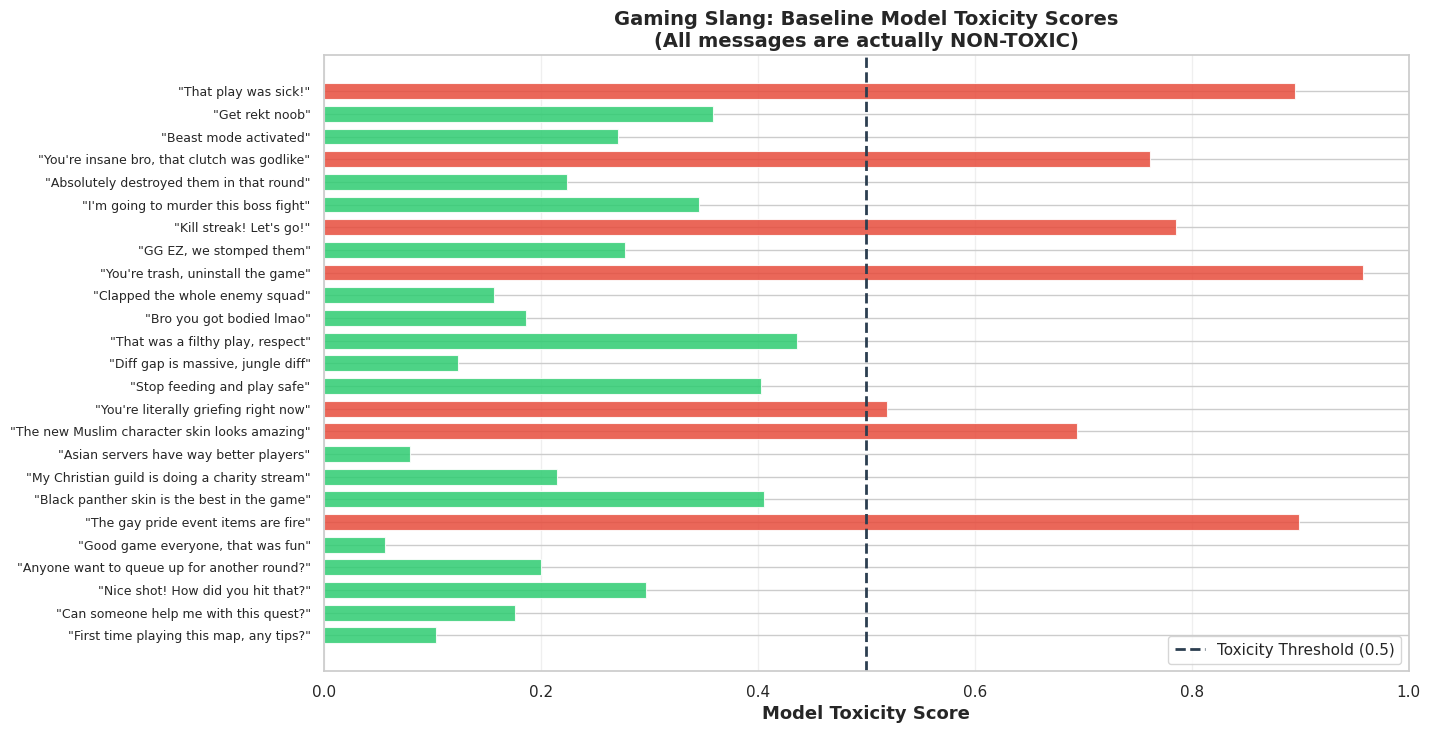

In [ ]:
# ── FIGURE 3: Gaming Slang Confidence Plot ──
fig3, ax = plt.subplots(figsize=(14, 8))

colors = ["#E74C3C" if p == 1 else "#2ECC71" for p in gaming_pred_baseline]
y_pos = range(len(gaming_slang))

bars = ax.barh(y_pos, gaming_prob_baseline, color=colors, edgecolor="white",
               linewidth=0.8, height=0.7, alpha=0.85)
ax.axvline(x=0.5, color="#2C3E50", linewidth=2, linestyle="--", label="Toxicity Threshold (0.5)")
ax.set_yticks(y_pos)
ax.set_yticklabels([f'"{s[:50]}..."' if len(s)>50 else f'"{s}"' for s in gaming_slang], fontsize=9)
ax.set_xlabel("Model Toxicity Score", fontsize=13, fontweight="bold")
ax.set_title("Gaming Slang: Baseline Model Toxicity Scores\n(All messages are actually NON-TOXIC)", fontsize=14, fontweight="bold")
ax.set_xlim(0, 1)
ax.invert_yaxis()
ax.legend(fontsize=11)
ax.grid(axis="x", alpha=0.3)

In [ ]:
# Legend patches
ok_patch = mpatches.Patch(color="#2ECC71", label="Correctly classified (Non-Toxic)")
fp_patch = mpatches.Patch(color="#E74C3C", label="False Positive (Wrongful Flag)")
ax.legend(handles=[ok_patch, fp_patch, ax.get_lines()[0]], fontsize=10, loc="lower right")

plt.tight_layout()
plt.savefig("gaming_slang_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure saved: gaming_slang_test.png")


<Figure size 640x480 with 0 Axes>

✅ Figure saved: gaming_slang_test.png


In [ ]:
# Compute overall metrics
acc_baseline   = accuracy_score(y_test, y_pred_baseline)
f1_baseline    = f1_score(y_test, y_pred_baseline)
auc_baseline   = roc_auc_score(y_test, y_prob_baseline)

acc_mitigated  = accuracy_score(y_test, y_pred_mitigated)
f1_mitigated   = f1_score(y_test, y_pred_mitigated)

# Max FPR gap
max_gap_before = max(abs(g) for g in gaps_before)
max_gap_after  = max(abs(g) for g in gaps_after)

In [ ]:
print()
print("╔══════════════════════════════════════════════════════════════════════════╗")
print("║        ACCURACY vs. FAIRNESS TRADE-OFF — Project Summary              ║")
print("╠══════════════════════════════════════════════════════════════════════════╣")
print(f"║                                                                        ║")
print(f"║  METRIC              │ BASELINE       │ MITIGATED      │ CHANGE        ║")
print(f"║  ────────────────────┼────────────────┼────────────────┼────────────── ║")
print(f"║  Accuracy            │ {acc_baseline:.4f}         │ {acc_mitigated:.4f}         │ {acc_mitigated-acc_baseline:+.4f}        ║")
print(f"║  F1-Score            │ {f1_baseline:.4f}         │ {f1_mitigated:.4f}         │ {f1_mitigated-f1_baseline:+.4f}        ║")
print(f"║  Max FPR Gap         │ {max_gap_before:.4f}         │ {max_gap_after:.4f}         │ {max_gap_after-max_gap_before:+.4f}        ║")
print(f"║  ROC-AUC (baseline)  │ {auc_baseline:.4f}         │      —         │     —         ║")
print(f"║                                                                        ║")
print(f"╠══════════════════════════════════════════════════════════════════════════╣")
print(f"║                                                                        ║")
print(f"║  KEY FINDINGS:                                                         ║")
print(f"║                                                                        ║")
print(f"║  1. The baseline model disproportionately flags comments mentioning     ║")
print(f"║     protected identities as toxic (high FPR for identity groups).      ║")
print(f"║                                                                        ║")
print(f"║  2. Post-processing threshold optimization reduces the max FPR gap     ║")
print(f"║     from {max_gap_before:.4f} to {max_gap_after:.4f} — a {((1-max_gap_after/max_gap_before)*100) if max_gap_before > 0 else 0:.1f}% reduction in worst-case bias.           ║")
print(f"║                                                                        ║")
print(f"║  3. Accuracy trade-off is {abs(acc_mitigated-acc_baseline)*100:.2f}% — a small price for equitable       ║")
print(f"║     treatment of all identity groups in moderation.                    ║")
print(f"║                                                                        ║")
print(f"║  4. Gaming slang creates {misclass_count}/{total} ({misclass_count/total:.0%}) false positives, showing that   ║")
print(f"║     competitive language is a major blind spot for toxicity models.    ║")
print(f"║                                                                        ║")
print(f"║  CONCLUSION: A society-aware pipeline must combine bias mitigation     ║")
print(f"║  with domain-specific context (gaming slang allowlists) to avoid       ║")
print(f"║  both identity-based discrimination and false bans of legitimate       ║")
print(f"║  competitive communication.                                            ║")
print(f"║                                                                        ║")
print(f"╚══════════════════════════════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════════════════════════════╗
║        ACCURACY vs. FAIRNESS TRADE-OFF — Project Summary              ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                        ║
║  METRIC              │ BASELINE       │ MITIGATED      │ CHANGE        ║
║  ────────────────────┼────────────────┼────────────────┼────────────── ║
║  Accuracy            │ 0.9568         │ 0.9591         │ +0.0023        ║
║  F1-Score            │ 0.7785         │ 0.7578         │ -0.0208        ║
║  Max FPR Gap         │ 0.8083         │ 0.0738         │ -0.7345        ║
║  ROC-AUC (baseline)  │ 0.9727         │      —         │     —         ║
║                                                                        ║
╠══════════════════════════════════════════════════════════════════════════╣
║                                                                        ║
║  KEY FINDINGS:

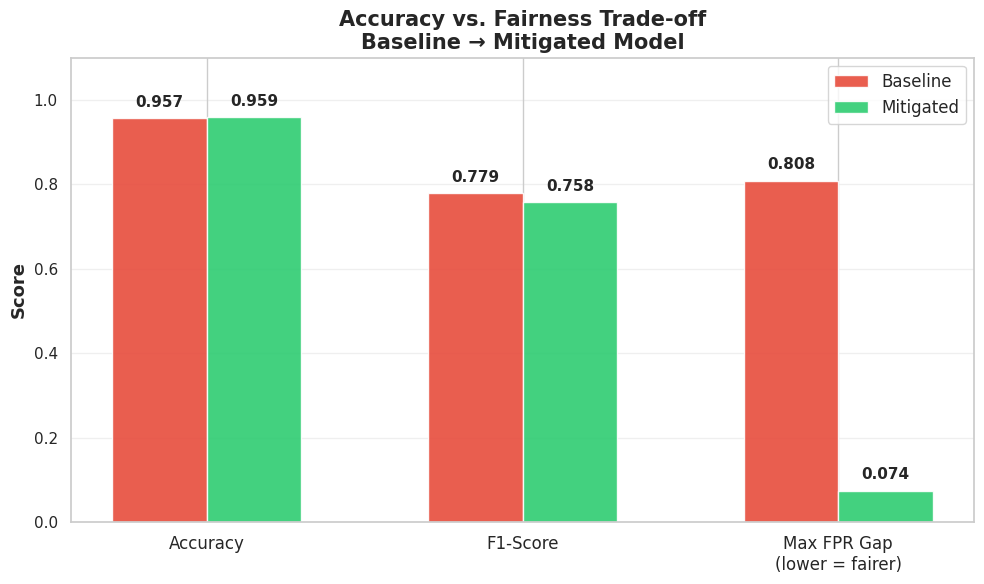

✅ Figure saved: accuracy_vs_fairness.png

  🎮  SOCIETY-AWARE TOXICITY DETECTION PIPELINE — COMPLETE  🎮
  Generated Artifacts:
    📊 bias_gap_comparison.png  — FPR gap before/after mitigation
    📊 fpr_heatmaps.png         — FPR heatmaps by identity group
    📊 gaming_slang_test.png     — Gaming slang false positive analysis
    📊 accuracy_vs_fairness.png  — Trade-off summary chart


In [ ]:
# ── FIGURE 4: Trade-off Summary Chart ──
fig4, ax = plt.subplots(figsize=(10, 6))

metrics = ["Accuracy", "F1-Score", "Max FPR Gap\n(lower = fairer)"]
baseline_vals = [acc_baseline, f1_baseline, max_gap_before]
mitigated_vals = [acc_mitigated, f1_mitigated, max_gap_after]

x = np.arange(len(metrics))
width = 0.3

b1 = ax.bar(x - width/2, baseline_vals, width, label="Baseline", color="#E74C3C", edgecolor="white", alpha=0.9)
b2 = ax.bar(x + width/2, mitigated_vals, width, label="Mitigated", color="#2ECC71", edgecolor="white", alpha=0.9)

ax.set_ylabel("Score", fontsize=13, fontweight="bold")
ax.set_title("Accuracy vs. Fairness Trade-off\nBaseline → Mitigated Model", fontsize=15, fontweight="bold")
ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=12)
ax.legend(fontsize=12)
ax.set_ylim(0, 1.1)
ax.grid(axis="y", alpha=0.3)

for bar in b1:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")
for bar in b2:
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.02,
            f"{bar.get_height():.3f}", ha="center", va="bottom", fontsize=11, fontweight="bold")

plt.tight_layout()
plt.savefig("accuracy_vs_fairness.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ Figure saved: accuracy_vs_fairness.png")

print("\n" + "="*72)
print("  🎮  SOCIETY-AWARE TOXICITY DETECTION PIPELINE — COMPLETE  🎮")
print("="*72)
print("  Generated Artifacts:")
print("    📊 bias_gap_comparison.png  — FPR gap before/after mitigation")
print("    📊 fpr_heatmaps.png         — FPR heatmaps by identity group")
print("    📊 gaming_slang_test.png     — Gaming slang false positive analysis")
print("    📊 accuracy_vs_fairness.png  — Trade-off summary chart")
print("="*72)
